In [ ]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, FIGURES_DIR, MOUSE_IDS_DUAL

from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pynapple as nap

states = ['wake', 'nrem', 'rem']
output_dir = FIGURES_DIR / "population_events"
output_dir.mkdir(parents=True, exist_ok=True)

## Detecting population events

### Per mouse

In [ ]:
def plot_events(mouse_id, event_rates, event_duration, fname=None):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"{mouse_id}", fontsize=16)

    axs[0].set_title("In event firing rate")
    for _, unit_rates in event_rates.iterrows():
        axs[0].plot(states, unit_rates, marker='o', linewidth=0.5, color='k', markersize=10)
    axs[0].plot(states, event_rates.mean(), marker='o', linewidth=1, color='r', markersize=10)
    axs[0].set_ylabel("Firing rate (Hz)")

    axs[1].plot(states, event_duration.values(), marker='o', linewidth=0.5, color='k', markersize=10)
    axs[1].set_title("Event duration")
    axs[1].set_ylabel("Event duration (s)")
    if fname is not None:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    
    return fig, axs

In [ ]:
bin_size = 0.001
for mouse_id in MOUSE_IDS_DUAL:
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    cw_units = turn_units[turn_units['is_cw']]

    event_rates = {}
    event_duration = {}

    # Get summed activity
    p = cw_units.count(bin_size=bin_size, time_units="s")
    p = p.sum(axis=1) / bin_size
    p = p.smooth(std=50, time_units="ms")

    for state in states:
        p_state = p.restrict(sleep[sleep['state'] == state])
        thr = p_state.mean() + 1 * p_state.std()
        population_events = p_state.threshold(thr).time_support

        print(mouse_id)
        print(f"{state} population activity: {p_state.mean():.3f} ± {p_state.std():.3f}")
        print(f"{state} population event threshold: {thr:.3f}")
        print(f"{state} detected population events: {len(population_events)}")
        print('--' * 50)

        duration = population_events.end - population_events.start
        result = cw_units.count(ep=population_events).to_numpy() / duration[:, None]
        
        event_rates[state] = np.nanmean(result, axis=0)
        event_duration[state] = duration.mean()

    event_rates = pd.DataFrame(event_rates, index=cw_units.keys())
    f, axs = plot_events(mouse_id, event_rates, event_duration, fname=output_dir / f"{mouse_id}.png")
    plt.close(f)

wake population activity: 124.319 ± 68.469
wake population event threshold: 192.787
wake detected population events: 11543
----------------------------------------------------------------------------------------------------
nrem population activity: 70.647 ± 39.802
nrem population event threshold: 110.449
nrem detected population events: 8326
----------------------------------------------------------------------------------------------------
rem population activity: 129.097 ± 75.540
rem population event threshold: 204.638
rem detected population events: 551
----------------------------------------------------------------------------------------------------
wake population activity: 83.877 ± 52.732
wake population event threshold: 136.609
wake detected population events: 13644
----------------------------------------------------------------------------------------------------
nrem population activity: 60.363 ± 33.725
nrem population event threshold: 94.088
nrem detected population event

### All mice

In [ ]:
event_rates = {'wake': [], 'nrem': [], 'rem': []}
event_duration = {'wake': [], 'nrem': [], 'rem': []}
index = []
bin_size = 0.001

for mouse_id in MOUSE_IDS_DUAL:
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    cw_units = turn_units[turn_units['is_cw']]
    
    print(mouse_id)
    if len(cw_units) < 5:
        print(f"{mouse_id} has {len(cw_units)}<5 CW units, skipping...")
        continue

    # Get summed activity
    # p = cw_units.count(bin_size=bin_size, time_units="s")
    p = turn_units.count(bin_size=bin_size, time_units="s")
    p = p.sum(axis=1) / bin_size
    p = p.smooth(std=50, time_units="ms")

    for state in states:
        p_state = p.restrict(sleep[sleep['state'] == state])
        thr = p_state.mean() + 1 * p_state.std()
        population_events = p_state.threshold(thr).time_support

        print(f"    {state} population activity: {p_state.mean():.3f} ± {p_state.std():.3f}")
        print(f"    {state} population event threshold: {thr:.3f}")
        print(f"    {state} detected population events: {len(population_events)}")
        print('--' * 25)

        duration = population_events.end - population_events.start
        # result = cw_units.count(ep=population_events).to_numpy() / duration[:, None]
        result = turn_units.count(ep=population_events).to_numpy() / duration[:, None]
        
        event_rates[state].append(result.mean())
        event_duration[state].append(duration.mean())
    index.append(mouse_id)
event_rates = pd.DataFrame(event_rates, index=index)
event_duration = pd.DataFrame(event_duration, index=index)

99b
    wake population activity: 180.777 ± 86.077
    wake population event threshold: 266.854
    wake detected population events: 13552
--------------------------------------------------
    nrem population activity: 111.402 ± 50.467
    nrem population event threshold: 161.869
    nrem detected population events: 9546
--------------------------------------------------
    rem population activity: 203.219 ± 110.406
    rem population event threshold: 313.625
    rem detected population events: 601
--------------------------------------------------
100b
    wake population activity: 171.570 ± 87.693
    wake population event threshold: 259.262
    wake detected population events: 13368
--------------------------------------------------
    nrem population activity: 106.630 ± 55.552
    nrem population event threshold: 162.182
    nrem detected population events: 9788
--------------------------------------------------
    rem population activity: 218.761 ± 125.421
    rem population e

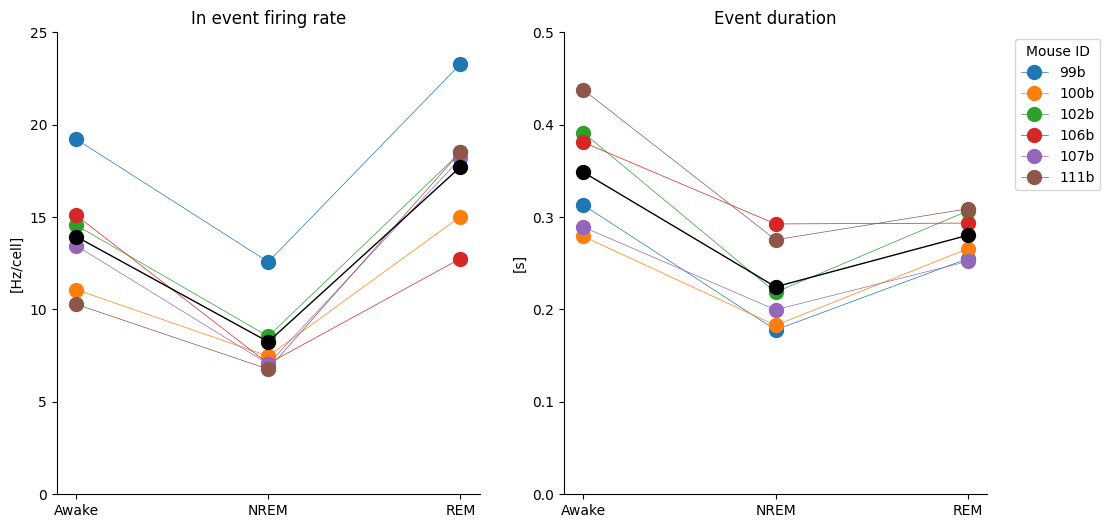

In [ ]:
fname = output_dir / "all_mice.png"

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
xlabels = ['Awake', 'NREM', 'REM']

for i in range(event_rates.shape[0]):
    axs[0].plot(xlabels, event_rates.iloc[i], marker='o', linewidth=0.5,  markersize=10, label=index[i])
    axs[1].plot(xlabels, event_duration.iloc[i], marker='o', linewidth=0.5, markersize=10, label=index[i])

axs[0].set_title("In event firing rate")
axs[0].plot(xlabels, event_rates.mean(), marker='o', linewidth=1, color='k', markersize=10)
axs[0].set_ylabel("[Hz/cell]")
# axs[0].set_ylim(0, 25)

axs[1].plot(xlabels, event_duration.mean(), marker='o', linewidth=1, color='k', markersize=10)
axs[1].set_title("Event duration")
axs[1].set_ylabel("[s]")
axs[1].set_ylim(0, 0.5)
plt.legend(title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig(fname, dpi=300, bbox_inches='tight')

In [158]:
mean_rates = event_rates.mean()
sem_rates = event_rates.sem()
mean_duration = event_duration.mean()
sem_duration = event_duration.sem()

for state in states:
    print(f"{state} event rate: {mean_rates[state]:.3f} ± {sem_rates[state]:.3f} Hz")
    print(f"{state} event duration: {mean_duration[state]:.3f} ± {sem_duration[state]:.3f} s")
    print('--' * 25)

wake event rate: 13.948 ± 1.309 Hz
wake event duration: 0.349 ± 0.026 s
--------------------------------------------------
nrem event rate: 8.249 ± 0.902 Hz
nrem event duration: 0.225 ± 0.020 s
--------------------------------------------------
rem event rate: 17.711 ± 1.464 Hz
rem event duration: 0.280 ± 0.011 s
--------------------------------------------------


## Inter-event interval

In [171]:
s = population_events.start
iei = s[1::] - s[0:-1:] # consecutive onset times
print(s[0:-1:])
print(s[0:-1:].shape)
print(s[1::])
print(s[1::].shape)
print(iei)

[ 6723.      6723.1235  6723.9075 ... 64719.0285 64719.5695 64719.8865]
(1385,)
[ 6723.1235  6723.9075  6724.7315 ... 64719.5695 64719.8865 64722.0535]
(1385,)
[0.1235 0.784  0.824  ... 0.541  0.317  2.167 ]


In [172]:
event_iei_mean = {'wake': [], 'nrem': [], 'rem': []}
event_iei_sem = {'wake': [], 'nrem': [], 'rem': []}
index = []
bin_size = 0.001

for mouse_id in MOUSE_IDS_DUAL:
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    cw_units = turn_units[turn_units['is_cw']]
    
    print(mouse_id)
    if len(cw_units) < 5:
        print(f"{mouse_id} has {len(cw_units)}<5 CW units, skipping...")
        continue

    # Get summed activity
    p = cw_units.count(bin_size=bin_size, time_units="s")
    # p = turn_units.count(bin_size=bin_size, time_units="s")
    p = p.sum(axis=1) / bin_size
    p = p.smooth(std=50, time_units="ms")

    for state in states:
        p_state = p.restrict(sleep[sleep['state'] == state])
        thr = p_state.mean() + 1 * p_state.std()
        population_events = p_state.threshold(thr).time_support
        iei = population_events.start[1::] - population_events.start[0:-1:]
        event_iei_mean[state].append(iei.mean())
        event_iei_sem[state].append(iei.std() / np.sqrt(len(iei)))
    index.append(mouse_id)

event_iei_mean = pd.DataFrame(event_iei_mean, index=index)
event_iei_sem = pd.DataFrame(event_iei_sem, index=index)

99b


KeyboardInterrupt: 